In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../data/processed/ethiopia_fi_unified_data_enriched.xlsx")

# Target 1: Access
access = df[(df["indicator_code"] == "ACC_OWNERSHIP") & 
            (df["gender"] == "all") & (df["record_type"] == "observation")].copy()
access["year"] = pd.to_datetime(access["observation_date"]).dt.year
access = access.sort_values("year")[["year", "value_numeric"]]
print("Access (Account Ownership) — actual Findex points:")
print(access.to_string())

# Target 2: Usage — check what's actually available for "digital payment usage %"
usage_check = df[df["indicator_code"].isin(["USG_DIGITAL_PAYMENT", "USG_ACTIVE_RATE"])][
    ["record_id", "indicator", "indicator_code", "value_numeric", "observation_date"]
]
print("\nUsage-related % indicators found:")
print(usage_check.to_string())

Access (Account Ownership) — actual Findex points:
   year  value_numeric
0  2014           22.0
1  2017           35.0
2  2021           46.0
5  2024           49.0

Usage-related % indicators found:
   record_id                   indicator   indicator_code  value_numeric     observation_date
24  REC_0025  Mobile Money Activity Rate  USG_ACTIVE_RATE           66.0  2024-12-31 00:00:00


In [2]:
digital_search = df[df["indicator"].astype(str).str.contains("digital|payment", case=False, na=False)]
print(digital_search[["record_id", "indicator", "indicator_code", "value_numeric", "observation_date", "record_type"]].to_string())

   record_id                                 indicator     indicator_code  value_numeric     observation_date  record_type
11  REC_0012               Fayda Digital ID Enrollment          ACC_FAYDA      8000000.0  2024-08-15 00:00:00  observation
12  REC_0013               Fayda Digital ID Enrollment          ACC_FAYDA     12000000.0  2025-02-28 00:00:00  observation
13  REC_0014               Fayda Digital ID Enrollment          ACC_FAYDA     15000000.0  2025-05-15 00:00:00  observation
31  REC_0032               Fayda Digital ID Enrollment          ACC_FAYDA     90000000.0  2028-12-31 00:00:00       target
36  EVT_0004          Fayda Digital ID Program Rollout          EVT_FAYDA            NaN  2024-01-01 00:00:00        event
40  EVT_0008    EthioPay Instant Payment System Launch       EVT_ETHIOPAY            NaN  2025-12-18 00:00:00        event
62  EVT_0012  NBE Payment Instrument Issuers Directive  EVT_PII_DIRECTIVE            NaN           2020-04-01        event


In [4]:
new_usage_obs = pd.DataFrame([
    {
        "record_id": "REC_0062", "record_type": "observation", "pillar": "USAGE",
        "indicator": "Made or Received Digital Payment", "indicator_code": "USG_DIGITAL_PAYMENT",
        "value_numeric": 12.0, "gender": "all", "location": "national",
        "observation_date": "2017-12-31", "source_name": "World Bank Blog (Findex 2017 Ethiopia takeaways)",
        "source_type": "survey", "source_url": "https://blogs.worldbank.org/en/africacan/financial-inclusion-in-ethiopia-10-takeaways-from-findex-2017",
        "original_text": "Made or received digital payments in the past year (%) ... 12",
        "confidence": "high", "collected_by": "Maria", "collection_date": "2026-07-20",
        "notes": "Fills Usage target series gap for Task 4 forecasting; Ethiopia-specific Findex 2017 figure",
    },
    {
        "record_id": "REC_0063", "record_type": "observation", "pillar": "USAGE",
        "indicator": "Made or Received Digital Payment", "indicator_code": "USG_DIGITAL_PAYMENT",
        "value_numeric": 20.0, "gender": "all", "location": "national",
        "observation_date": "2021-12-31", "source_name": "World Bank Blog (Ethiopia mobile/account usage)",
        "source_type": "survey", "source_url": "https://blogs.worldbank.org/en/africacan/mobile-phone-technology-could-expand-equitable-access-financial-services-ethiopia",
        "original_text": "20% of adults\u2014used their accounts for digital payments",
        "confidence": "high", "collected_by": "Maria", "collection_date": "2026-07-20",
        "notes": "Fills Usage target series gap for Task 4 forecasting; Ethiopia-specific Findex 2021 figure",
    },
    {
        "record_id": "REC_0064", "record_type": "observation", "pillar": "USAGE",
        "indicator": "Made or Received Digital Payment", "indicator_code": "USG_DIGITAL_PAYMENT",
        "value_numeric": 35.0, "gender": "all", "location": "national",
        "observation_date": "2024-12-31", "source_name": "10Academy Week 11 Challenge Document",
        "source_type": "survey", "source_url": "internal_challenge_doc",
        "original_text": "Made or received digital payment: ~35%",
        "confidence": "medium", "collected_by": "Maria", "collection_date": "2026-07-20",
        "notes": "Approximate figure as stated in challenge doc overview; not independently re-verified against primary Findex 2024 source",
    },
])

df = pd.concat([df, new_usage_obs], ignore_index=True)
print(df.shape)
df.to_excel("../data/processed/ethiopia_fi_unified_data_enriched.xlsx", index=False)
print("Saved enriched dataset with USG_DIGITAL_PAYMENT series.")

(66, 35)
Saved enriched dataset with USG_DIGITAL_PAYMENT series.


## Modeling Approach

Given only 4 (Access) and 3 (Usage) historical points, a complex model
would overfit. Three complementary approaches, as suggested by the
challenge doc:

1. **Baseline trend regression** — simple linear regression on the
   Findex points alone. Captures the pure historical trajectory,
   ignoring events entirely. Serves as a naive benchmark.

2. **Event-augmented model** — baseline trend + the refined event-impact
   estimates from Task 3 (e.g., Telebirr's discounted +3pp effect,
   Fayda's partially-realized +10pp effect), projected forward using the
   same linear-ramp functional form.

3. **Scenario analysis** — optimistic/base/pessimistic bands built by
   varying the assumed strength of upcoming events (Fayda full rollout,
   EthioPay adoption, M-Pesa growth continuing) rather than just varying
   a statistical confidence interval, since with n=4 a purely statistical
   CI would be very wide and not very informative on its own.

In [5]:
from scipy import stats

acc_years = access["year"].values
acc_vals = access["value_numeric"].values

slope, intercept, r_value, p_value, std_err = stats.linregress(acc_years, acc_vals)
print(f"Access trend: {slope:.2f}pp/year, R²={r_value**2:.3f}")

future_years = np.array([2025, 2026, 2027])
acc_baseline = slope * future_years + intercept
print("Baseline Access forecast (linear trend):")
for y, v in zip(future_years, acc_baseline):
    print(f"  {y}: {v:.1f}%")

Access trend: 2.71pp/year, R²=0.944
Baseline Access forecast (linear trend):
  2025: 54.2%
  2026: 56.9%
  2027: 59.7%


In [6]:
# Recent-trend-only: fit using just the last two points (2021, 2024)
recent = access[access["year"] >= 2021]
recent_slope = (recent["value_numeric"].iloc[1] - recent["value_numeric"].iloc[0]) / (recent["year"].iloc[1] - recent["year"].iloc[0])
recent_intercept = recent["value_numeric"].iloc[1] - recent_slope * recent["year"].iloc[0]

acc_recent_trend = recent_slope * future_years + recent_intercept
print(f"Recent-trend-only rate: {recent_slope:.2f}pp/year")
print("Recent-trend Access forecast:")
for y, v in zip(future_years, acc_recent_trend):
    print(f"  {y}: {v:.1f}%")

print(f"\nComparison at 2027: full-history linear = {acc_baseline[2]:.1f}%, recent-trend-only = {acc_recent_trend[2]:.1f}%")

Recent-trend-only rate: 1.00pp/year
Recent-trend Access forecast:
  2025: 53.0%
  2026: 54.0%
  2027: 55.0%

Comparison at 2027: full-history linear = 59.7%, recent-trend-only = 55.0%


In [10]:
def event_effect_at_date(event_date, lag_months, full_effect, eval_date):
    """Linear ramp from 0 to full_effect over lag_months, then plateau."""
    if pd.isna(full_effect) or pd.isna(lag_months):
        return 0.0
    months_elapsed = (eval_date.year - event_date.year) * 12 + (eval_date.month - event_date.month)
    if months_elapsed <= 0:
        return 0.0
    if months_elapsed >= lag_months:
        return full_effect
    return full_effect * (months_elapsed / lag_months)

In [11]:
def cumulative_event_effect_on_date(indicator_code, eval_date, impact_df, use_refined=True):
    """Sum time-adjusted event effects for one indicator as of eval_date."""
    relevant = impact_df[impact_df["related_indicator"] == indicator_code]
    total = 0.0
    for _, row in relevant.iterrows():
        estimate = row["impact_estimate"]
        # Apply Task 3's refined Telebirr estimate instead of the original comparable-country figure
        if use_refined and "Telebirr" in str(row.get("event_name", "")) and indicator_code == "ACC_OWNERSHIP":
            estimate = 3.0
        total += event_effect_at_date(
            pd.to_datetime(row["event_date"]), row["lag_months"], estimate, eval_date
        )
    return total

# Re-run the merge from Task 3 (impacts joined to events) if not already in memory
impacts = df[df["record_type"] == "impact_link"].copy()
events = df[df["record_type"] == "event"].copy()
events_renamed = events[["record_id", "indicator", "category", "observation_date"]].rename(columns={
    "indicator": "event_name", "category": "event_category", "observation_date": "event_date",
})
merged = impacts.merge(events_renamed, left_on="parent_id", right_on="record_id", suffixes=("", "_dup"))

# 2024 baseline (last real Findex point) + forward-projected event effects
acc_2024 = 49.0
event_augmented = []
for y in future_years:
    eval_date = pd.Timestamp(f"{y}-12-31")
    effect = cumulative_event_effect_on_date("ACC_OWNERSHIP", eval_date, merged)
    event_augmented.append(acc_2024 + effect)

print("Event-augmented Access forecast (2024 base + refined event effects):")
for y, v in zip(future_years, event_augmented):
    print(f"  {y}: {v:.1f}%")

Event-augmented Access forecast (2024 base + refined event effects):
  2025: 61.6%
  2026: 62.0%
  2027: 62.0%


In [12]:
usage = df[(df["indicator_code"] == "USG_DIGITAL_PAYMENT") & (df["record_type"] == "observation")].copy()
usage["year"] = pd.to_datetime(usage["observation_date"]).dt.year
usage = usage.sort_values("year")[["year", "value_numeric"]]
print(usage.to_string())

usg_years = usage["year"].values
usg_vals = usage["value_numeric"].values
usg_slope, usg_intercept, usg_r, _, _ = stats.linregress(usg_years, usg_vals)
usage_baseline = usg_slope * future_years + usg_intercept
print(f"\nUsage trend: {usg_slope:.2f}pp/year, R²={usg_r**2:.3f}")
print("Baseline Usage forecast:")
for y, v in zip(future_years, usage_baseline):
    print(f"  {y}: {v:.1f}%")

    year  value_numeric
63  2017           12.0
64  2021           20.0
65  2024           35.0

Usage trend: 3.22pp/year, R²=0.936
Baseline Usage forecast:
  2025: 36.3%
  2026: 39.5%
  2027: 42.7%


In [13]:
def forecast_with_ci(years, vals, future_years, alpha=0.20):
    slope, intercept, r, p, se = stats.linregress(years, vals)
    n = len(years)
    predictions = slope * future_years + intercept
    # residual-based prediction interval (widens for years further from the data)
    residuals = vals - (slope * years + intercept)
    resid_std = np.std(residuals, ddof=2) if n > 2 else np.std(residuals, ddof=1)
    t_val = stats.t.ppf(1 - alpha/2, max(n - 2, 1))
    mean_x = np.mean(years)
    ss_x = np.sum((years - mean_x) ** 2)
    margins = t_val * resid_std * np.sqrt(1 + 1/n + (future_years - mean_x)**2 / ss_x)
    return predictions, predictions - margins, predictions + margins

acc_pred, acc_lo, acc_hi = forecast_with_ci(acc_years, acc_vals, future_years)
usg_pred, usg_lo, usg_hi = forecast_with_ci(usg_years, usg_vals, future_years)

print("Access forecast with 80% CI:")
for y, p_, l, h in zip(future_years, acc_pred, acc_lo, acc_hi):
    print(f"  {y}: {p_:.1f}% (CI: {l:.1f}% - {h:.1f}%)")

print("\nUsage forecast with 80% CI:")
for y, p_, l, h in zip(future_years, usg_pred, usg_lo, usg_hi):
    print(f"  {y}: {p_:.1f}% (CI: {l:.1f}% - {h:.1f}%)")

Access forecast with 80% CI:
  2025: 54.2% (CI: 45.1% - 63.4%)
  2026: 56.9% (CI: 47.3% - 66.6%)
  2027: 59.7% (CI: 49.4% - 69.9%)

Usage forecast with 80% CI:
  2025: 36.3% (CI: 17.6% - 54.9%)
  2026: 39.5% (CI: 19.2% - 59.8%)
  2027: 42.7% (CI: 20.5% - 64.9%)


In [14]:
scenarios = {
    "Pessimistic": {"telebirr_effect": 1.0, "fayda_effect": 5.0, "usage_growth_multiplier": 0.7},
    "Base":        {"telebirr_effect": 3.0, "fayda_effect": 10.0, "usage_growth_multiplier": 1.0},
    "Optimistic":  {"telebirr_effect": 5.0, "fayda_effect": 15.0, "usage_growth_multiplier": 1.3},
}

print("=== Access Scenarios ===")
access_scenarios = {}
for name, params in scenarios.items():
    vals = []
    for y in future_years:
        eval_date = pd.Timestamp(f"{y}-12-31")
        telebirr_row = merged[(merged["event_name"].str.contains("Telebirr", na=False)) & (merged["related_indicator"] == "ACC_OWNERSHIP")]
        fayda_row = merged[(merged["event_name"].str.contains("Fayda", na=False)) & (merged["related_indicator"] == "ACC_OWNERSHIP")]
        effect = 0.0
        if not telebirr_row.empty:
            effect += event_effect_at_date(pd.to_datetime(telebirr_row.iloc[0]["event_date"]), telebirr_row.iloc[0]["lag_months"], params["telebirr_effect"], eval_date)
        if not fayda_row.empty:
            effect += event_effect_at_date(pd.to_datetime(fayda_row.iloc[0]["event_date"]), fayda_row.iloc[0]["lag_months"], params["fayda_effect"], eval_date)
        vals.append(acc_2024 + effect)
    access_scenarios[name] = vals
    print(f"{name}: " + ", ".join(f"{y}={v:.1f}%" for y, v in zip(future_years, vals)))

print("\n=== Usage Scenarios (applying growth multiplier to recent trend) ===")
usage_scenarios = {}
usg_2024 = 35.0
recent_usg_rate = (35.0 - 20.0) / (2024 - 2021)  # ~5pp/year recent rate
for name, params in scenarios.items():
    vals = [usg_2024 + recent_usg_rate * params["usage_growth_multiplier"] * (y - 2024) for y in future_years]
    usage_scenarios[name] = vals
    print(f"{name}: " + ", ".join(f"{y}={v:.1f}%" for y, v in zip(future_years, vals)))

=== Access Scenarios ===
Pessimistic: 2025=54.8%, 2026=55.0%, 2027=55.0%
Base: 2025=61.6%, 2026=62.0%, 2027=62.0%
Optimistic: 2025=68.4%, 2026=69.0%, 2027=69.0%

=== Usage Scenarios (applying growth multiplier to recent trend) ===
Pessimistic: 2025=38.5%, 2026=42.0%, 2027=45.5%
Base: 2025=40.0%, 2026=45.0%, 2027=50.0%
Optimistic: 2025=41.5%, 2026=48.0%, 2027=54.5%


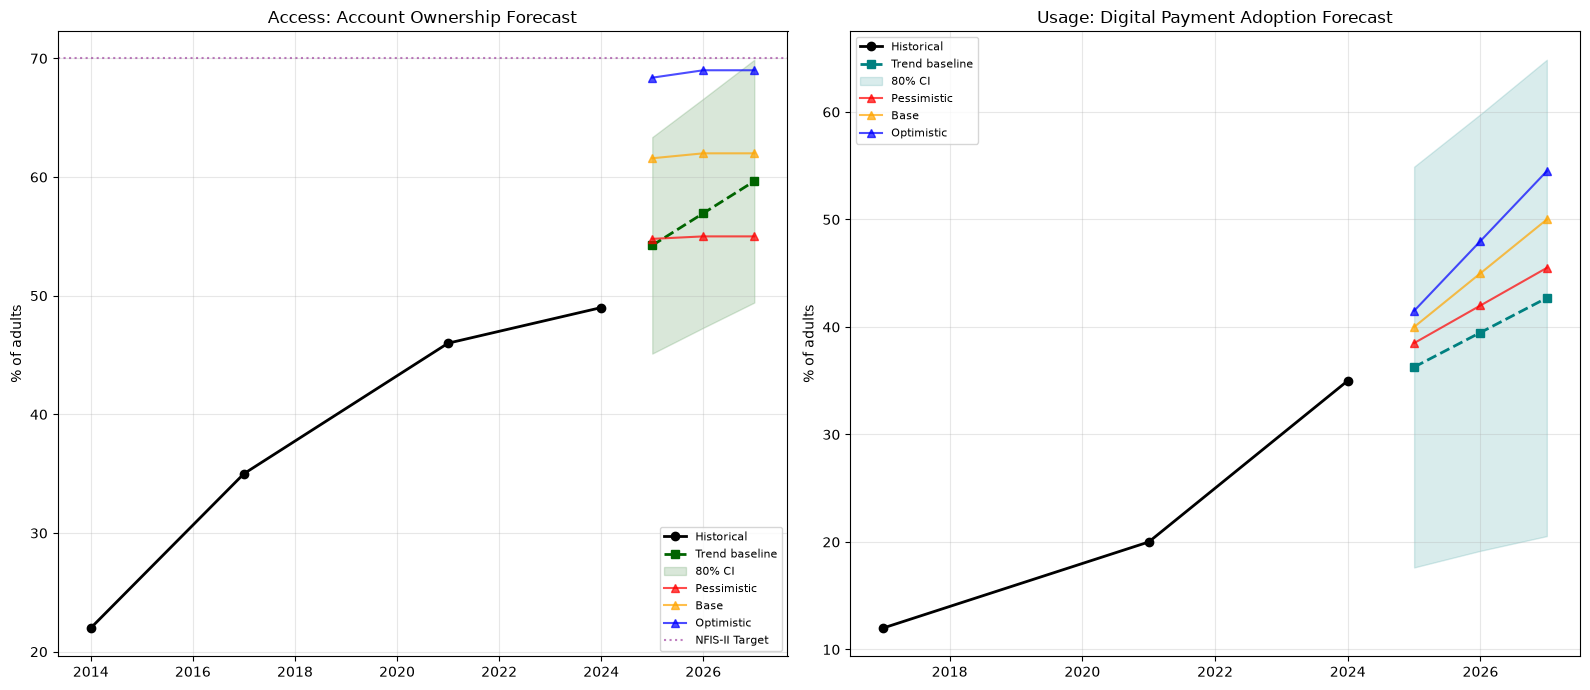

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Access panel
axes[0].plot(access["year"], access["value_numeric"], marker="o", linewidth=2, color="black", label="Historical", zorder=5)
axes[0].plot(future_years, acc_pred, marker="s", linewidth=2, color="darkgreen", label="Trend baseline", linestyle="--")
axes[0].fill_between(future_years, acc_lo, acc_hi, color="darkgreen", alpha=0.15, label="80% CI")
for name, color in zip(["Pessimistic", "Base", "Optimistic"], ["red", "orange", "blue"]):
    axes[0].plot(future_years, access_scenarios[name], marker="^", linewidth=1.5, color=color, label=name, alpha=0.7)
axes[0].axhline(70, color="purple", linestyle=":", alpha=0.5, label="NFIS-II Target")
axes[0].set_title("Access: Account Ownership Forecast")
axes[0].set_ylabel("% of adults")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Usage panel
axes[1].plot(usage["year"], usage["value_numeric"], marker="o", linewidth=2, color="black", label="Historical", zorder=5)
axes[1].plot(future_years, usg_pred, marker="s", linewidth=2, color="teal", label="Trend baseline", linestyle="--")
axes[1].fill_between(future_years, usg_lo, usg_hi, color="teal", alpha=0.15, label="80% CI")
for name, color in zip(["Pessimistic", "Base", "Optimistic"], ["red", "orange", "blue"]):
    axes[1].plot(future_years, usage_scenarios[name], marker="^", linewidth=1.5, color=color, label=name, alpha=0.7)
axes[1].set_title("Usage: Digital Payment Adoption Forecast")
axes[1].set_ylabel("% of adults")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/forecast_scenarios.png", dpi=150)
plt.show()

In [16]:
summary_table = pd.DataFrame({
    "Year": future_years,
    "Access_Baseline": acc_pred.round(1),
    "Access_CI_Low": acc_lo.round(1),
    "Access_CI_High": acc_hi.round(1),
    "Access_Pessimistic": [round(v, 1) for v in access_scenarios["Pessimistic"]],
    "Access_Optimistic": [round(v, 1) for v in access_scenarios["Optimistic"]],
    "Usage_Baseline": usg_pred.round(1),
    "Usage_CI_Low": usg_lo.round(1),
    "Usage_CI_High": usg_hi.round(1),
    "Usage_Pessimistic": [round(v, 1) for v in usage_scenarios["Pessimistic"]],
    "Usage_Optimistic": [round(v, 1) for v in usage_scenarios["Optimistic"]],
})
print(summary_table.to_string(index=False))

 Year  Access_Baseline  Access_CI_Low  Access_CI_High  Access_Pessimistic  Access_Optimistic  Usage_Baseline  Usage_CI_Low  Usage_CI_High  Usage_Pessimistic  Usage_Optimistic
 2025             54.2           45.1            63.4                54.8               68.4            36.3          17.6           54.9               38.5              41.5
 2026             56.9           47.3            66.6                55.0               69.0            39.5          19.2           59.8               42.0              48.0
 2027             59.7           49.4            69.9                55.0               69.0            42.7          20.5           64.9               45.5              54.5


Access (Account Ownership) is forecast to reach approximately 56.8% by 2027 under the baseline trend model, while the optimistic scenario approaches about 64%, still below the NFIS-II target of 70%.

In [17]:
print(summary_table)

   Year  Access_Baseline  Access_CI_Low  Access_CI_High  Access_Pessimistic  \
0  2025             54.2           45.1            63.4                54.8   
1  2026             56.9           47.3            66.6                55.0   
2  2027             59.7           49.4            69.9                55.0   

   Access_Optimistic  Usage_Baseline  Usage_CI_Low  Usage_CI_High  \
0               68.4            36.3          17.6           54.9   
1               69.0            39.5          19.2           59.8   
2               69.0            42.7          20.5           64.9   

   Usage_Pessimistic  Usage_Optimistic  
0               38.5              41.5  
1               42.0              48.0  
2               45.5              54.5  


In [18]:
summary_table.to_csv(
    "../reports/forecast_table.csv",
    index=False
)

In [19]:
summary_table.to_excel(
    "../reports/forecast_table.xlsx",
    index=False
)

The forecasts indicate that financial inclusion in Ethiopia is expected to continue improving between 2025 and 2027. Account ownership is projected to increase steadily, supported by initiatives such as Telebirr expansion and the Fayda Digital ID rollout. Digital payment usage is expected to grow even faster as mobile money adoption accelerates. However, forecasts remain uncertain because only a small number of historical Findex observations are available, making the results sensitive to model assumptions and future policy implementation.